In [1]:
from moabb.paradigms import P300,LeftRightImagery, MotorImagery
from moabb.datasets import *
from mne.decoding import Scaler


paradigm = MotorImagery(resample=250)
dataset = AlexMI()
epochs, labels, meta = paradigm.get_data(
     dataset=dataset, 
     subjects=[1],
     return_epochs=True
)
session = meta['session'].unique()[0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]

Choosing from all possible events


Adding metadata with 3 columns
Adding metadata with 3 columns
60 matching events found
No baseline correction applied


/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 60 events (all good), 0 – 3 s (baseline off), ~11.3 MB, data loaded,
 'right_hand': 20
 'feet': 20
 'rest': 20>
  warn(f"warnEpochs {epochs}")
/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/paradigms/base.py:350: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [2]:
epochs

<EpochsArray | 60 events (all good), 0 – 2.996 s (baseline off), ~5.5 MB, data loaded, with metadata,
 'right_hand': 20
 'feet': 20
 'rest': 20>

In [3]:
import plotly.io as pio
pio.renderers.default = 'iframe'

In [4]:
%load_ext autoreload
%autoreload 2

No projector specified for this dataset. Please consider the method self.add_proj.


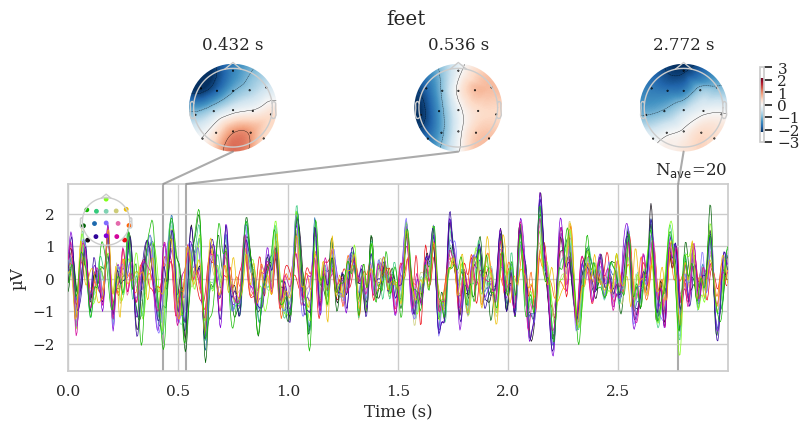

No projector specified for this dataset. Please consider the method self.add_proj.


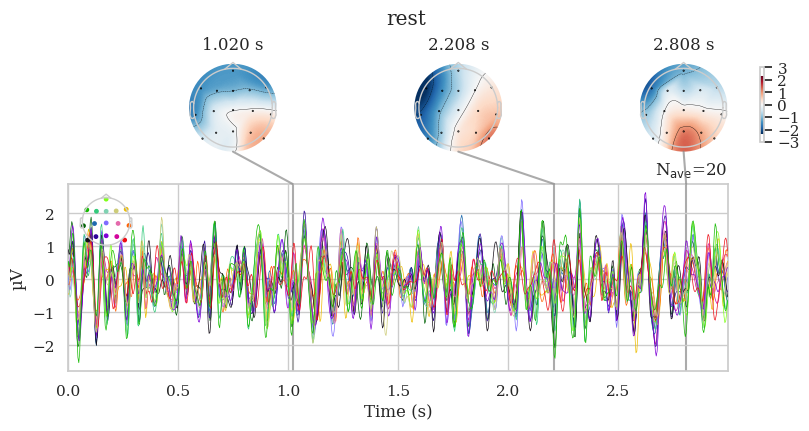

No projector specified for this dataset. Please consider the method self.add_proj.


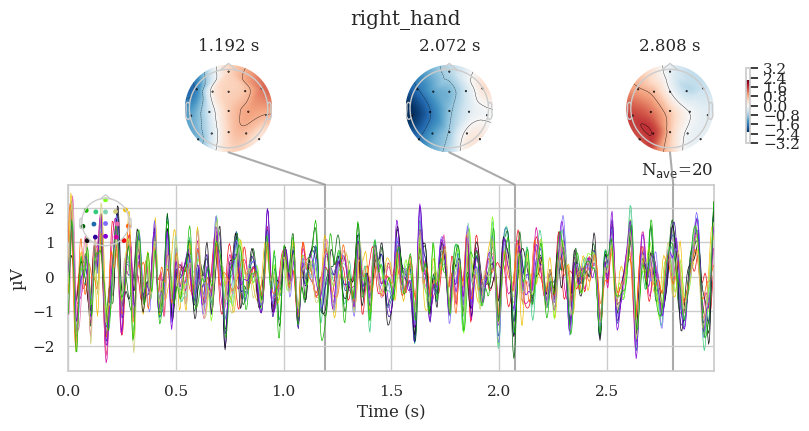

In [5]:
import numpy as np
ts_args=dict(ylim=dict(
    #eeg=[-15,15]
))
joint_args=dict(ts_args=ts_args)
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    if len(evoked.ch_names) > 1:
        evoked.plot_joint(title=cls, **joint_args)
    else:
        evoked.plot(**ts_args)

In [6]:
from hoda.tensorize import stf_tensor
from sklearn.preprocessing import StandardScaler
import tensorly as tl
from mne.decoding import Scaler
X = epochs.get_data()
print(X.shape)

y = labels
X = Scaler(scalings='mean', with_mean=True).fit_transform(X)
X, freqs = stf_tensor(X, sfreq=epochs.info['sfreq'],normalize=True, log=True, return_freqs=True)
X = tl.tensor(X)
X.shape

(60, 16, 750)


(60, 16, 8, 96)

/tmp/ipykernel_3652093/3370167951.py:4: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: ylabel='Density'>

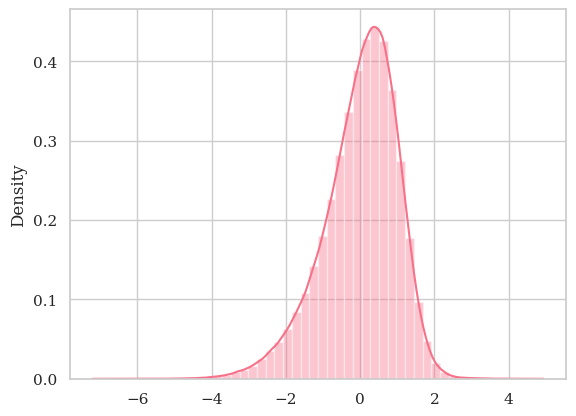

In [7]:
import seaborn as sns
x = X[:,:,:,:].flatten()
x = tl.to_numpy(x)
sns.distplot(x)

/tmp/ipykernel_3652093/2101837038.py:2: RuntimeWarning:

Mean of empty slice.

/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning:

invalid value encountered in divide

/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/seaborn/matrix.py:202: RuntimeWarning:

All-NaN slice encountered

/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/seaborn/matrix.py:207: RuntimeWarning:

All-NaN slice encountered



[Text(0, 0.5, '8.0'),
 Text(0, 1.5, '9.513656920021768'),
 Text(0, 2.5, '11.313708498984761'),
 Text(0, 3.5, '13.454342644059432'),
 Text(0, 4.5, '16.0'),
 Text(0, 5.5, '19.027313840043536'),
 Text(0, 6.5, '22.627416997969526'),
 Text(0, 7.5, '26.908685288118868')]

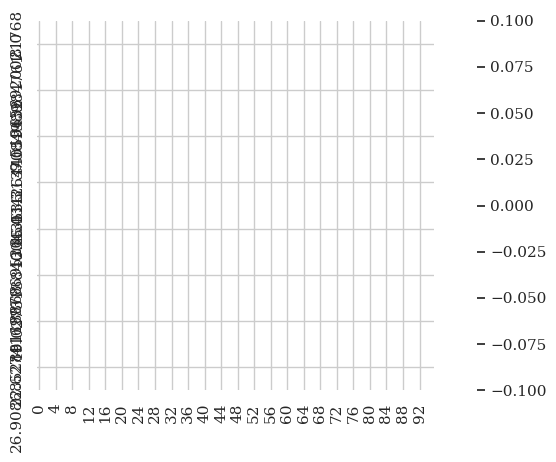

In [8]:
import seaborn as sns
contrast = tl.to_numpy(X[y=='right_hand'].mean(axis=0)) - tl.to_numpy(X[y=='left_hand'].mean(axis=0))
ax = sns.heatmap(contrast[2], cmap="vlag", center=0, square=False)
ax.set_yticklabels(freqs[:-1])

In [9]:
from hoda.hoda import HODA

hoda = HODA(
        rank=None,
        max_iter=1024,
        tol=0,
        shrinkage='lw',
        toeplitz=(2,),
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=True,
        verbose=True,
        random_state=42,
        forward=True,
        theta=0.2,
)


In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')

hoda.fit_backward(X,y)
df = pd.DataFrame(hoda.train_info_['backward'])
display(df)

/vsc-hard-mounts/leuven-data/352/vsc35289/hoda-bci/src/hoda/util.py:26: RuntimeWarning:

k >= N for N * N square matrix. Attempting to use scipy.linalg.eigh instead.

Backward HODA model rank=(1, 1, 3):   0%|          | 3/1024 [00:00<00:34, 29.67it/s]

[624.42400675]
[414.45955699]
[1169.06737511  403.71243939  -31.12718091]
[196.81157698]
[85.46053945]
[192.93066083  51.67447699 -67.79530285]
[49.2148151]
[4.82066375]
[ 78.4854034    4.21960295 -57.25013713]
[25.40912615]
[3.7332581]
[ 59.90933901  -4.22060002 -45.11307415]
[14.52513319]
[3.26963611]
[ 52.07583602  -7.15152892 -38.53570027]
[8.28240275]
[3.39372598]
[ 48.98389276  -8.89235006 -35.44351092]
[5.16242153]


Backward HODA model rank=(1, 1, 3):   1%|          | 11/1024 [00:00<00:35, 28.70it/s]

[3.48248636]
[ 48.22611421 -10.56888315 -34.0066308 ]
[3.51303448]
[3.27619973]
[ 48.40536443 -12.27451491 -33.06837228]
[2.86373916]
[2.75258107]
[ 48.148645   -13.5691062  -32.11930235]
[2.41360835]
[1.78280403]
[ 47.09235684 -14.11377067 -31.25891778]
[1.55694046]
[0.95734392]
[ 45.83799045 -14.25589514 -30.51964415]
[1.0142907]
[0.44592219]
[ 44.86923981 -14.27954786 -29.9570088 ]


Backward HODA model rank=(1, 1, 3):   2%|▏         | 19/1024 [00:00<00:30, 33.38it/s]

...

Backward HODA model rank=(1, 1, 3):  99%|█████████▉| 1015/1024 [00:26<00:00, 42.12it/s]

[ 66.63604358 -32.39162551 -34.2442538 ]
[0.0001307]
[0.00011118]
[ 66.66334565 -32.40597169 -34.25729813]
[7.52472947e-05]
[6.23525751e-05]
[ 66.68559535 -32.41818169 -34.26736952]
[5.32473002e-05]
[4.56444251e-05]
[ 66.70283773 -32.42804372 -34.27475999]
[4.25007414e-05]
[3.85823845e-05]
[ 66.71551268 -32.43561498 -34.27986808]
[3.43895947e-05]
[3.27163514e-05]
[ 66.7242735  -32.44111965 -34.2831285 ]
[2.66523513e-05]
[2.61539739e-05]
[ 66.72985323 -32.44486902 -34.28496396]
[1.93896874e-05]
[1.93848633e-05]
[ 66.73297396 -32.44720352 -34.28575552]
[1.31737278e-05]
[1.32942364e-05]
[ 66.73429113 -32.4484537  -34.28582726]
[8.35493527e-06]
[8.44252295e-06]


Backward HODA model rank=(1, 1, 3): 100%|██████████| 1024/1024 [00:26<00:00, 38.75it/s]
/vsc-hard-mounts/leuven-data/352/vsc35289/hoda-bci/src/hoda/hoda.py:351: UserWarning:

Maximum number of iterations reached without convergence



[ 66.73436437 -32.44891672 -34.28544124]
[4.94971252e-06]
[4.9646394e-06]
[ 66.73364737 -32.44884428 -34.28479936]
[2.74446673e-06]
[2.70045029e-06]
[ 66.73249025 -32.44843889 -34.28404934]
[1.433445e-06]
[1.35905908e-06]
[ 66.7311495 -32.4478556 -34.2832929]
[7.19418611e-07]
[6.39607481e-07]
[ 66.72980187 -32.44720685 -34.28259455]


,iteration,mode,update,shrinkage,objective,F_tr,F_rt
0,1,0,0.811155,0.030243,171230.581707,0.088692,0.013369
1,1,1,0.699188,0.050156,149527.082736,0.140432,0.021275
2,1,2,1.360602,0.372761,69478.253527,0.714503,0.070814
3,2,0,0.514888,0.047090,95332.163060,0.859894,0.087112
4,2,1,0.298433,0.126782,131627.335815,0.951645,0.097867
...,...,...,...,...,...,...,...
3067,1023,1,0.000075,0.315424,131342.050594,3.094130,0.231922
3068,1023,2,0.000098,0.354313,21169.202836,3.094207,0.231927
3069,1024,0,0.000057,0.107473,41400.092339,3.094223,0.231928
3070,1024,1,0.000050,0.315425,131341.401892,3.094222,0.231928


In [11]:
df['flip'] = (df['iteration']-1)*2+df['mode']
df

,iteration,mode,update,shrinkage,objective,F_tr,F_rt,flip
0,1,0,0.811155,0.030243,171230.581707,0.088692,0.013369,0
1,1,1,0.699188,0.050156,149527.082736,0.140432,0.021275,1
2,1,2,1.360602,0.372761,69478.253527,0.714503,0.070814,2
3,2,0,0.514888,0.047090,95332.163060,0.859894,0.087112,2
4,2,1,0.298433,0.126782,131627.335815,0.951645,0.097867,3
...,...,...,...,...,...,...,...,...
3067,1023,1,0.000075,0.315424,131342.050594,3.094130,0.231922,2045
3068,1023,2,0.000098,0.354313,21169.202836,3.094207,0.231927,2046
3069,1024,0,0.000057,0.107473,41400.092339,3.094223,0.231928,2046
3070,1024,1,0.000050,0.315425,131341.401892,3.094222,0.231928,2047


In [12]:
import plotly.express as px

fig = px.line(df, x='flip', y='F_tr', log_y=False)
fig.show()

In [13]:
px.line(df, x='iteration', y='update', log_y=True, color='mode')


In [14]:
px.line(df, x='flip', y='shrinkage', log_y=True, color='mode')

In [15]:
px.line(df, x='flip', y='objective', log_y=True, color='mode')

In [16]:
hoda.fit_forward(X,y)
df = pd.DataFrame(hoda.train_info_['forward'])
df

Forward model : 100%|██████████| 1024/1024 [00:30<00:00, 33.50it/s]


,iteration,mode,update,shrinkage,mse,nmse
0,0,0,inf,NaN,0.999525,0.999525
1,0,1,inf,NaN,0.999525,0.999525
2,0,2,inf,NaN,0.999525,0.999525
3,1,0,1.293846e+00,0.000000,0.998730,0.998730
4,1,1,4.818585e-01,0.000000,0.998435,0.998435
...,...,...,...,...,...,...
3067,1022,1,2.363733e-16,0.000000,0.989115,0.989115
3068,1022,2,8.085227e-03,0.001031,0.989116,0.989116
3069,1023,0,8.151131e-03,0.000000,0.989115,0.989115
3070,1023,1,1.743837e-16,0.000000,0.989115,0.989115


In [17]:
df['flip'] = (df['iteration']-1)*2+df['mode']
df

,iteration,mode,update,shrinkage,mse,nmse,flip
0,0,0,inf,NaN,0.999525,0.999525,-2
1,0,1,inf,NaN,0.999525,0.999525,-1
2,0,2,inf,NaN,0.999525,0.999525,0
3,1,0,1.293846e+00,0.000000,0.998730,0.998730,0
4,1,1,4.818585e-01,0.000000,0.998435,0.998435,1
...,...,...,...,...,...,...,...
3067,1022,1,2.363733e-16,0.000000,0.989115,0.989115,2043
3068,1022,2,8.085227e-03,0.001031,0.989116,0.989116,2044
3069,1023,0,8.151131e-03,0.000000,0.989115,0.989115,2044
3070,1023,1,1.743837e-16,0.000000,0.989115,0.989115,2045


In [18]:
px.line(df, x='flip', y='mse', log_y=True)

In [19]:
px.line(df, x='flip', y='update', log_y=True, color='mode')

In [20]:
from sklearn.feature_selection import SelectFpr, SelectFwe, SelectFdr
import numpy as np

Xt = hoda.transform(X)
xt = tl.to_numpy(tl.unfold(Xt,0))

select = SelectFdr(alpha=.05)
xts = select.fit_transform(xt,y)

df = pd.DataFrame({
    'feature': np.arange(xt.shape[-1]),
    'F': select.scores_,
    'p_value': select.pvalues_,
    'significant': select.get_support()
})
df

,feature,F,p_value,significant
0,0,99.979169,2.297979e-19,True
1,1,28.950522,2.104748e-09,True
2,2,0.678917,5.112191e-01,False


In [21]:
fig = px.bar(df, x='feature', y='F', color='significant', log_y=True)
fig.update_xaxes(type='category', categoryorder='total descending')
fig.show()

In [22]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
x_viz = TSNE(n_components=2).fit_transform(xts)
px.scatter(x=x_viz[:,0], y=x_viz[:,1], color=y)